# Data Analysis 

In [ ]:
import duckdb
from pathlib import Path
import re
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.tsa.stattools as ts
import statsmodels.graphics.tsaplots as tp
import statsmodels.stats.diagnostic as dg
import seaborn as sns

import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning

warnings.filterwarnings('ignore', category=InterpolationWarning)

DB_PATH = Path("spiff_data.db")
TABLE_NAME = "transformed_data"

CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

In [121]:
def distribution_summary(df: pd.DataFrame) -> pd.DataFrame:
    numeric_cols = df.columns
    summary_data = []
    for col in numeric_cols:
        summary_data.append({
            "column": col,
            "mean": df[col].mean(),
            "stddev": df[col].std(),
            "skewness": df[col].skew(),
            "excess kurtosis": df[col].kurtosis(),  # excess Kurtosis
            "normality_pvalue": stats.normaltest(df[col].dropna())[1]
        })

    return pd.DataFrame(summary_data)

In [ ]:
def get_valid_segments_fixed(series):
    mask = series.notna().to_numpy()
    padded = np.concatenate([[False], mask, [False]])
    diff = np.diff(padded.astype(int))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]
    return list(zip(starts, ends))


def temporal_analysis(df: pd.DataFrame) -> pd.DataFrame:
    summary_data = []
    for col in df.columns:
        # calculate the adf/kpss results for all valid intervals longger than 20
        valid_interval = get_valid_segments_fixed(df[col]) 

        adf_result = [ts.adfuller(df[col].iloc[st:ed])[1] for st, ed in valid_interval if (ed - st > 20)]
        kpss_result =  [ts.kpss(df[col].iloc[st:ed])[1] for st, ed in valid_interval if (ed - st > 20)]

        summary_data.append({
            "adf_pvalue": adf_result,
            "adf_stationary":max(adf_result) <0.05, 
            "kpss_pvalue": kpss_result,
            "kpss_stationary":min(kpss_result) > 0.05, 
            "segments": valid_interval
        })

        # plot the ACF for the longest continuous series
        valid_arr = np.array(valid_interval)

        best_idx  = (valid_arr[:, 1] - valid_arr[:, 0]).argmax()
        st, ed = valid_interval[best_idx]
        segment = df[col].iloc[st:ed] 
        returns_centered = segment - segment.mean()
        returns_centered2 = returns_centered.pow(2)

        plot_acf_dir = CHART_DIR / "ACF_Plots"
        Path.mkdir(plot_acf_dir, exist_ok=True)
        fig, ax = plt.subplots(1, 3, figsize=(4*3, 4), sharex=True)
        name = col.split('_')[0]
        tp.plot_acf(returns_centered, lags=20, ax=ax[0], markersize=4, title=f"ACF of {name}")
        tp.plot_pacf(returns_centered, lags=20, ax=ax[1], markersize=4, method="ywm", title=f"PACF of {name}")
        tp.plot_acf(returns_centered2, lags=20, ax=ax[2], markersize=4, title=f"ACF of {name}_squared")
        # tp.plot_pacf(returns_centered2, lags=20, ax=ax[3], markersize=4, method="ywm", title=f"PACF of {name}")

        ax[0].set_xlabel("Lag")
        ax[1].set_xlabel("Lag")
        ax[2].set_xlabel("Lag")
        # ax[3].set_xlabel("Lag")

        ax[0].set_ylabel("ACF")
        ax[1].set_ylabel("PACF")
        ax[2].set_ylabel("ACF")
        # ax[3].set_ylabel("PACF")

        plt.tight_layout()
        # plt.savefig(plot_acf_dir / f"(P)ACF_{col}.jpg", dpi=180)
        # plt.close()

        lb_p = dg.acorr_ljungbox(
            returns_centered,
            lags=20,
            boxpierce=False,
            model_df=0,
            period=None,
            return_df=True,
            auto_lag=False
        )["lb_pvalue"]
        lb2_p = dg.acorr_ljungbox(
            returns_centered2,
            lags=20,
            boxpierce=False,
            model_df=0,
            period=None,
            return_df=True,
            auto_lag=False
        )["lb_pvalue"]

        summary_data[-1].update({
            "lb_pvalue": lb_p.min(),
            "lb2_pvalue": lb2_p.min(),
        })

    return pd.DataFrame(summary_data, index=df.columns)

In [ ]:
def correlation_analysis(df: pd.DataFrame, min_periods=30) -> pd.DataFrame:
    # Correlation Matrix
    numeric_cols = df.columns
    correlation_matrix = df[numeric_cols].corr(min_periods=30)

    return correlation_matrix

In [131]:
with duckdb.connect(DB_PATH) as conn:
    cols = conn.execute("DESCRIBE transformed_data").df()["column_name"].tolist()
    val_cols = [c for c in cols if "logreturn" in c]
    df = conn.execute(f"SELECT day, {', '.join(val_cols)} FROM {TABLE_NAME}").df()

print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
df.head()

Rows: 5355, Columns: 8


,day,gurkor_logreturn,guitars_logreturn,slingshots_logreturn,stocks_logreturn,sugar_logreturn,water_logreturn,tranquillity_logreturn
0,2,0.002461,0.007516,-0.004691,0.000846,0.004010,0.000420,0.001422
1,3,-0.001475,-0.000523,0.000566,0.005976,-0.002502,-0.000280,0.005815
2,4,-0.000863,-0.002494,-0.004165,0.001059,-0.006318,0.000419,-0.002106
3,5,-0.002226,0.001446,0.000760,0.000477,0.002032,0.000466,0.001931
4,6,0.001485,0.004957,0.001895,-0.001778,0.000000,0.000605,-0.001755


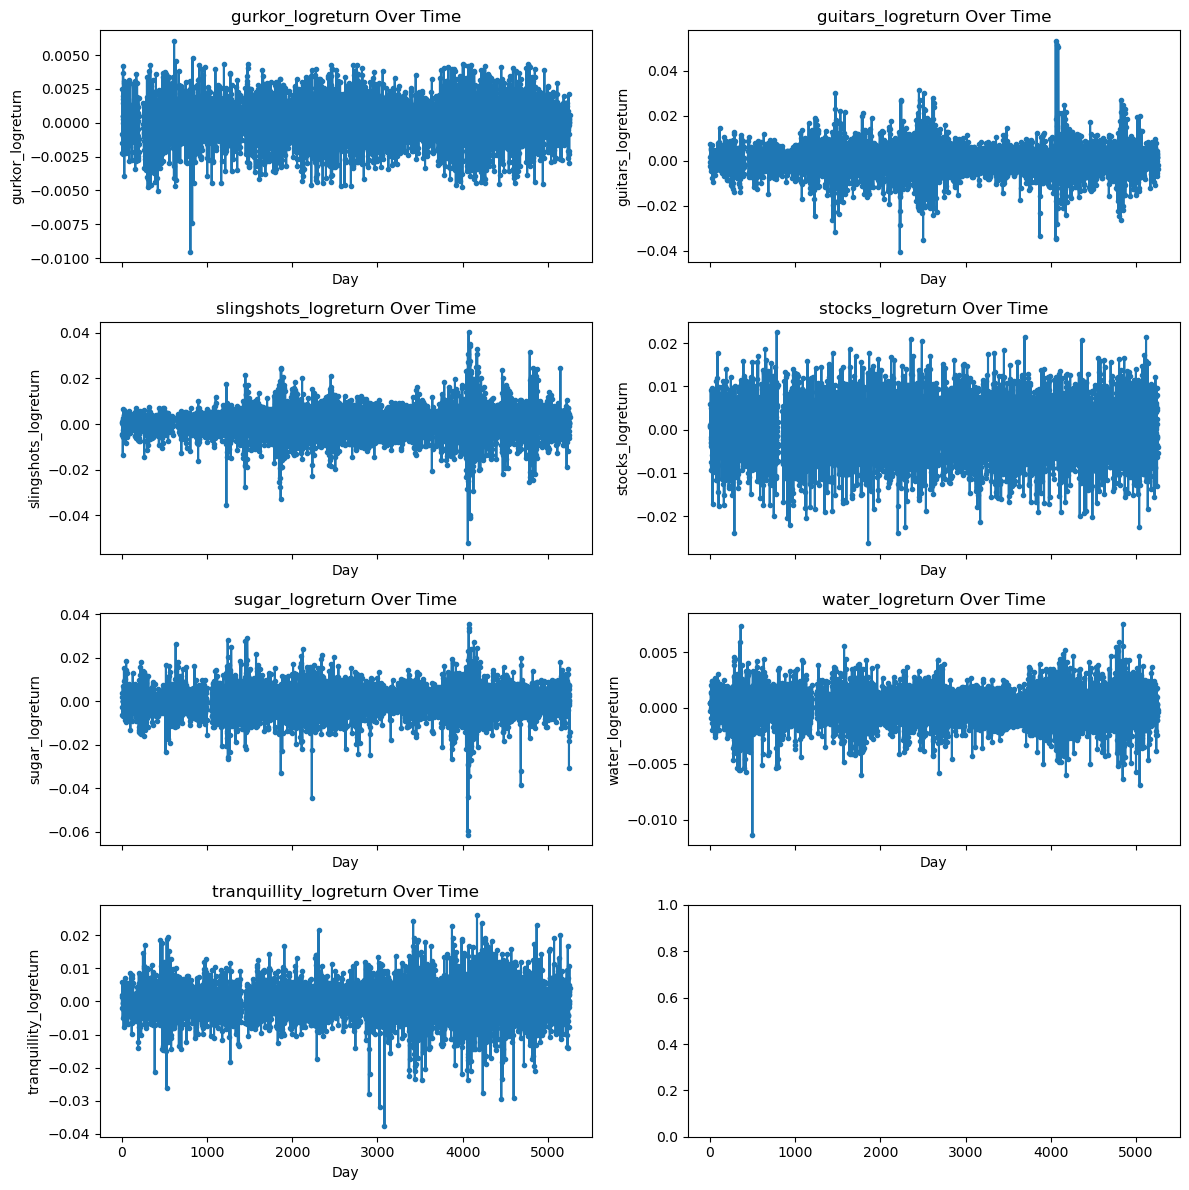

In [132]:
TEMPORAL_DIR = Path("Temporal_Analysis")
Path.mkdir(CHART_DIR / TEMPORAL_DIR, exist_ok=True)

# Line plots of raw log returns
ncols = 2
nrows = int(np.ceil(len(val_cols)/2))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows*3), sharex=True)
axes = axes.flatten() 
for i, col in enumerate(val_cols):
    ax = axes[i]
    ax.plot(df["day"], df[col], marker="o", linestyle="-", markersize=3)
    ax.set_title(f"{col} Over Time")
    ax.set_xlabel("Day")
    ax.set_ylabel(col)

fig.tight_layout()
plt.show()
# plt.close()

#### Data Preprocessing & Distributional Characteristics
We observed isolated spikes in the dataset for several sequences. For example, the log-return of gukor exhibits some isolated and unreasonable spikes alongside time-varying volatility, where the latter period shows higher dispersion. Here, we adopt a rolling median (less senstive to the outliers & dynamic view of data) to help smooth a time series that might have outliers without hurting the underlying trends, using a sliding window of 150 observations (~3%) and a threshold of 5 Median Absolute Deviations (MAD).

To ensure data integrity, detected outliers were flagged and replaced with NaNs, followed by linear interpolation. This approach effectively suppresses impulse noise while maintaining the continuous temporal structure of the log-returns, leading to a more robust estimation of volatility and higher-order moments (skewness and kurtosis).

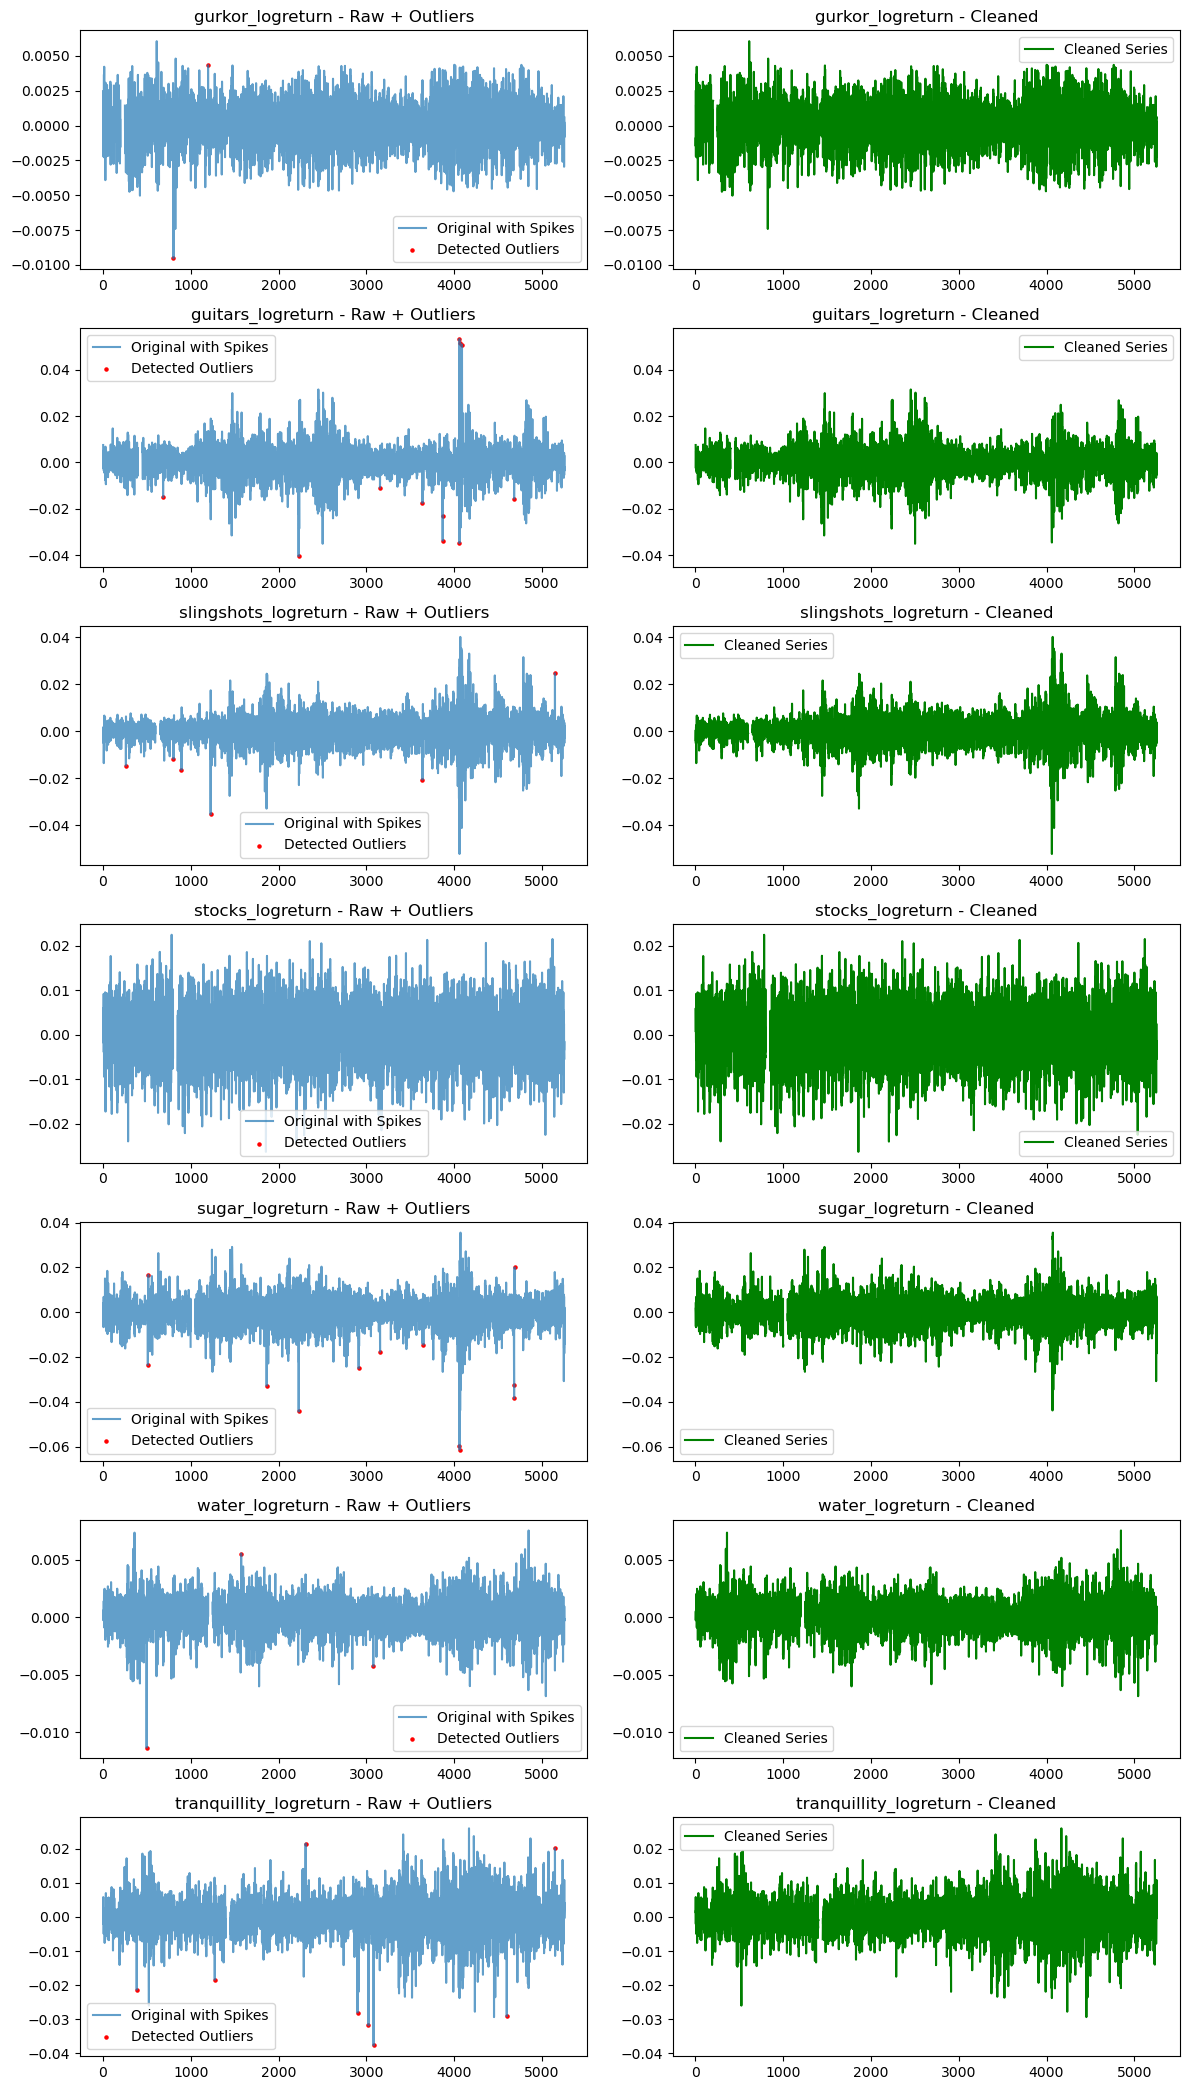

Distributional analysis before cleaning:


,column,mean,stddev,skewness,excess kurtosis,normality_pvalue,normality_flag
0,gurkor_logreturn,0.000072,0.001529,-0.177398,0.702877,1.811876e-19,False
1,guitars_logreturn,0.000134,0.006285,0.021152,5.678209,4.763223e-136,False
2,slingshots_logreturn,0.000123,0.006144,-0.237097,5.380161,8.337312e-141,False
3,stocks_logreturn,-0.000041,0.006480,-0.115073,0.073449,2.068543e-03,False
4,sugar_logreturn,-0.000013,0.006414,-0.560856,6.258909,1.183811e-196,False
5,water_logreturn,0.000067,0.001478,-0.246775,2.080191,7.396829e-66,False
6,tranquillity_logreturn,0.000056,0.005406,-0.237116,2.987118,1.462349e-89,False


Distributional analysis after cleaning:


,column,mean,stddev,skewness,excess kurtosis,normality_pvalue,normality_flag
0,gurkor_logreturn,0.000074,0.001522,-0.138560,0.450093,1.104848e-10,False
1,guitars_logreturn,0.000129,0.006090,-0.205348,3.017602,6.453823e-88,False
2,slingshots_logreturn,0.000140,0.006097,-0.209224,5.319413,1.298945e-137,False
3,stocks_logreturn,-0.000045,0.006479,-0.113579,0.072949,2.394442e-03,False
4,sugar_logreturn,0.000037,0.006191,-0.097317,2.874739,2.212018e-78,False
5,water_logreturn,0.000069,0.001465,-0.169117,1.475645,3.305581e-42,False
6,tranquillity_logreturn,0.000082,0.005301,-0.094393,2.212734,2.248815e-60,False


In [133]:
if "df" not in globals() or "val_cols" not in globals():
    raise RuntimeError("Run the data loading cell first.")

# Handling extreme values
df1 = df.set_index("day")

def clean_spikes(s, window=150, toleratance=5):
    """"
    clean spikes in a pandas Series using a rolling median and median absolute deviation(MAD) approach. 
    It identifies outliers based on the deviation from the rolling median, scaled by the MAD, 
    and replaces them with NaN before interpolating to fill the gaps.
    """
    rolling_median = s.rolling(window=window, center=True).median()

    def get_mad(x):
        m = np.median(x)
        return np.median(np.abs(x - m))
    
    rolling_mad = s.rolling(window=window, center=True, min_periods=1).apply(get_mad)
    is_outlier = (s - rolling_median).abs() > toleratance * (1.4826 * rolling_mad)
    s_clean = s.copy()
    s_clean[is_outlier] = np.nan

    # Interpolate to fill the NaN values created by outlier removal with a limit of 2 to prevent over-smoothing
    s_clean = s_clean.interpolate(method='linear', limit=2) 
    return s_clean, is_outlier

ncols = 2
nrows = len(val_cols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3*nrows))
axes = axes.flatten() 

df_clean = df1.copy()
for i, col in enumerate(val_cols):
    row = int(i//2)
    ax0 = axes[2*i]
    ax1 = axes[2*i+1]
    df_clean[col], outliers = clean_spikes(df1[col])

    ax0.plot(df1.index, df1[col], label='Original with Spikes', alpha=0.7)
    ax0.scatter(df1.index[outliers], df1.loc[outliers, col], color='red', label='Detected Outliers', s=5)
    current_ylim = ax0.get_ylim()
    ax0.set_title(f"{col} - Raw + Outliers")
    ax0.legend()

    ax1.plot(df_clean.index, df_clean[col], label='Cleaned Series', color='green')
    ax1.set_ylim(current_ylim)
    ax1.set_title(f"{col} - Cleaned")
    ax1.legend()

plt.tight_layout()
plt.show()

dis_summary = distribution_summary(df1)
dis_summary["normality_flag"] = dis_summary["normality_pvalue"] > 0.05
print("Distributional analysis before cleaning:")
display(dis_summary)
print("Distributional analysis after cleaning:")
dis_summary_clean = distribution_summary(df_clean)
dis_summary_clean["normality_flag"] = dis_summary_clean["normality_pvalue"] > 0.05
display(dis_summary_clean)

Here, we present distributional analysis comparing the dataset of log-returns before and after the data cleaning process. 
- **Bias correction(Mean):** The mean values across most assets remained nearly identical to their raw state, which confirms that the cleaning process is unbiased, removing local noise without shifting the long-term expected returns. Note that the most critical shift occurred in "sugar_logreturn", where the mean flipped from negative to positive. This indicates the removal of extreme negative outliers that were distorting the asset's true performance.

- **Volatility Stabilization(Stddev):** A universal reduction in standard deviation across all assets confirms the effective suppression of non-representative variance-inflating noise.

- **Symmetry(Skewness):** Most assets show negative skewness (long left tails, implying more extreme losses than gains). Cleaning slightly adjusted these values, suggesting that some extreme negative outliers were neutralized. 
Note that "guitars_logreturn" experienced the shift from a slight positive skewness (0.021) to a negative one (-0.205). The original positive skew was an artifact caused by extreme upward outliers (spikes reaching 0.05). By removing these unrepresentative spikes, the process has revealed the asset's true underlying distribution, which is characterized by a natural, slight negative bias and a much healthier kurtosis of 3.01. 
Also, there exists a dramatic improvement in the skewness of sugar_logreturn (from -0.56 to -0.09) is a direct result of the suppression of extreme negative impulses. The raw data was heavily biased by rare, deep downward spikes that created an artificial 'long-tail' risk. By neutralizing these outliers, the cleaning process has restored the symmetry of the return distribution, aligning it with its true economic performance and making it more suitable for standard risk-management models.

- **Normalization of Tails(Excess Kurtosis):** High kurtosis signifies "heavy tails" or frequent extreme outliers. The data cleaning process effectively addressed the excess kurtosis across the portfolio by suppressing variance-inflating "spikes" while preserving fundamental distributional characteristics. 
For assets such as sugar_logreturn and guitars_logreturn, the significant reduction in excess kurtosis (e.g., sugar dropping from +6.26 to +2.87) indicates the successful neutralization of non-representative impulse noise, resulting in a distribution less prone to artificial extremes. 
Crucially, the resilience of slingshots_logreturn, which maintained a high excess kurtosis (+5.38 to +5.31), demonstrates the selective and robust nature of the cleaning process, which accurately targets erratic data glitches while respecting the inherent leptokurtic (fat-tailed) nature of assets with naturally high risk profiles. 

We provide both the P-value and a Normality Flag to assess the distributional nature of the cleaned data. Despite the significant reduction in excess kurtosis, the P-values remain well below the 0.05 threshold, resulting in a False flag across all assets. This indicates that while the cleaning removed non-representative noise, the underlying log-returns still possess their inherent non-Gaussian characteristics (e.g., residual fat tails), which is a well-documented property of financial time series.


We further utilizing Quantile-quantile plots to help visualize the static distribution and evaluate the asset's overall normality and residual tail risk, by comparing the quantiles of sample data against theoretical quantiles (normal). This further confirms whether the remaining extremes represent consistent market behavior or isolated shocks.
- Stocks is the only asset that adheres strictly to a Normal (Gaussian) Distribution. Its data points follow the reference line almost perfectly, supported by a near-zero excess kurtosis (0.07).
- Slingshots, guitars, gugar display aggressive "S-curves" and high excess kurtosis (5.32, 3.02, 2.87). Even after removing outliers, the data points plunge significantly below the line on the left and surge above it on the right. This indicates that the "standard" assumption of normality is invalid, and the intrinsic volatility of these assets produces extreme gains and losses far more frequently. Additionally, sugar and slingshots show slightly more pronounced deviations on the left tail compared to the right, suggesting a negative skewness where extreme drawdowns are more severe than extreme rallies.
- Tranquillity, water, gurkor show moderate deviations, with excess kurtosis ranging from 0.45 to 2.21. They appear stable in the "typical" trading range (the center), they still possess a residual risk of extreme movements that exceeds normal expectations.

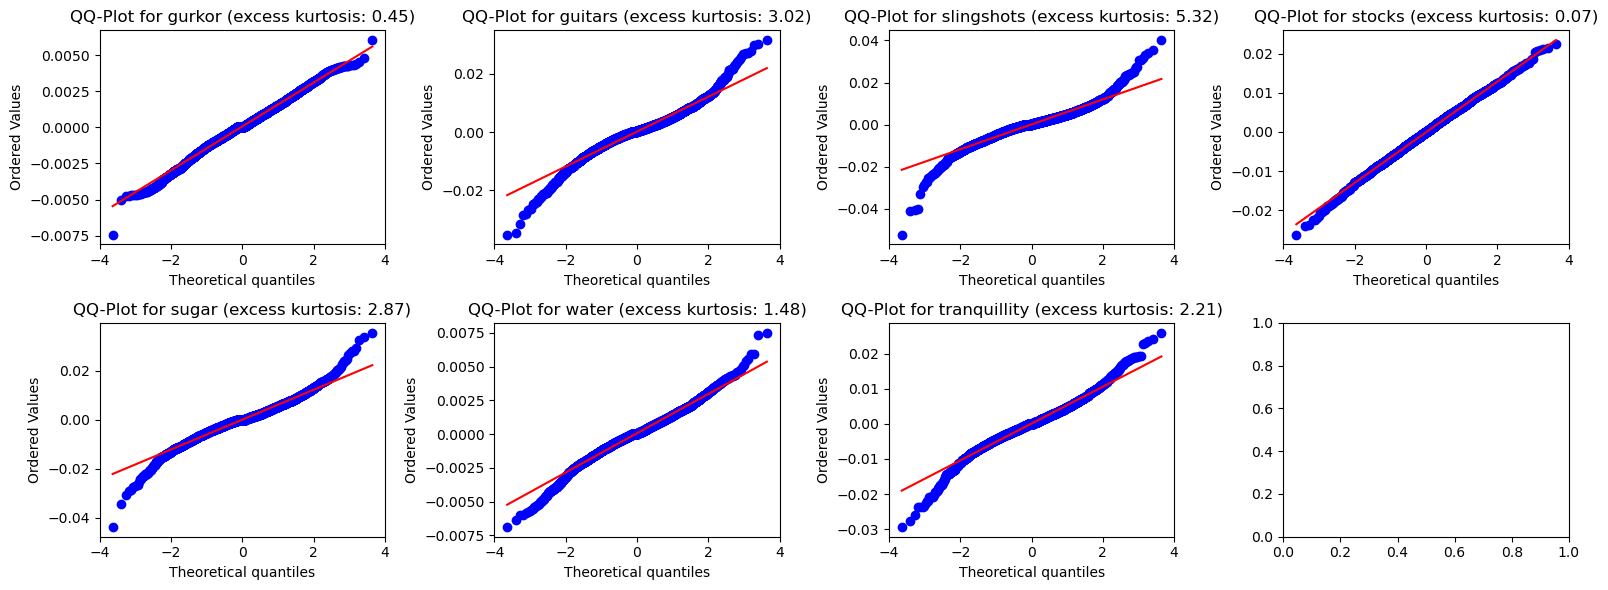

In [204]:
if "dis_summary_clean" not in globals() or "df" not in globals():
    raise RuntimeError("Run distribution and data loading cells first.")

target_cols = dis_summary_clean[dis_summary_clean["excess kurtosis"] > 0]["column"].tolist()
QQ_DIR = Path("QQ_Plots")
Path.mkdir(CHART_DIR / QQ_DIR, exist_ok=True)

nrows = 2
ncols = len(target_cols)//2 +(len(target_cols)%2 !=0)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()
for i, col in enumerate(target_cols):
    name = col.split('_')[0]
    kurt_val = dis_summary_clean.loc[dis_summary["column"] == col, "excess kurtosis"].values[0]
    stats.probplot(df_clean[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(f"QQ-Plot for {name} (excess kurtosis: {kurt_val:.2f})")
fig.tight_layout()
plt.show()

#### Temporal Properties & Stationarity Analysis
Before examining the temporal properties of the cleaned data, we first assess its continuity by identifying the structure and distribution of missing values. <br>
- Initial diagnostics reveal approximately 247 missing observations (~4.7%) per asset. <br>
- To understand the distribution, we computed the Rolling Missing Ratio. As illustrated in the visualization, the missing data does not occur randomly but concentrated, particularly in a large block at the end of the series, i.e., a minor cluster in the early stage (indices 0–1500) and a major contiguous block at the end (starting around index 5150). <br>

Missing values by column:


gurkor_logreturn          247
guitars_logreturn         247
slingshots_logreturn      247
stocks_logreturn          247
water_logreturn           247
tranquillity_logreturn    247
sugar_logreturn           246
dtype: int64

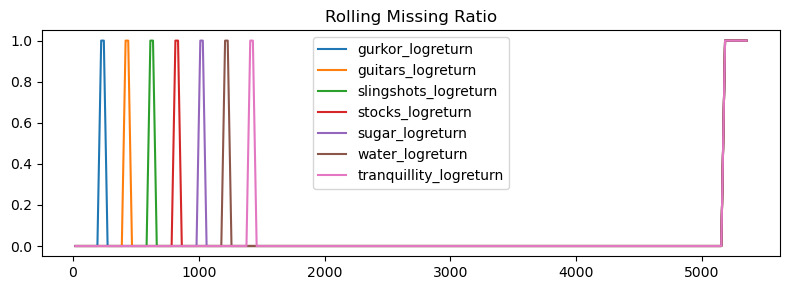

In [113]:
# Mssing value analysis
missing_counts = df_clean.isna().sum().sort_values(ascending=False)
print("Missing values by column:")
display(missing_counts)

plt.figure(figsize=(8, 3))
for col in val_cols:
    df[col].isna().rolling(30, min_periods=20).mean().plot(label=col) # the percentage of missing values within the window, spotting trends in data loss
plt.title(f"Rolling Missing Ratio")
plt.legend()
plt.tight_layout()
plt.show()

To preserve the integrity of the temporal structure, we avoid naive deletion or concatenation, which would artificially treat distant observations as adjacent and bias our inference. Instead, the series is partitioned into discrete, continuous segments. Specifically, we employ a dual-track validation strategy:
1. We conduct analysis across all continuous segments to verify the consistency of statistical patterns throughout the entire observation period, such as the Augmented Dickey–Fuller (ADF) and KPSS tests. 
2. For depth-dependent modeling (e.g., estimating long-term temporal dependencies), we utilize only the largest continuous segment. This ensures that the estimated dynamics are derived from a high-fidelity sequence, free from the biases typically induced by missing intervals or improper joins.

While the QQ-Plots provides the "static" profile of the data, which highlights the presence of fat tails in most of the datasets, we further compute the 30-day rolling volatility to analyze the temporal structure of risk, i.e.,to determine whether observed "fat-tail" is a result of structural regime shifts or the well-documented phenomenon of volatility clustering (autocorrelated shocks). By isolating the largest continuous data segment, we ensure that the rolling window remains free from interpolation artifacts, providing a cleaner narrative of the asset’s historical stress periods. 

Based on the provided visualizations, the "fat-tail" nature of these assets appears to be driven by a combination of both volatility clustering and structural regime shifts, though the dominant force varies by asset. 
- Most assets in the panel, specifically guitars, slingshots, sugar, and water, exhibit classic symptoms of volatility clustering. This suggests that the fat-tails in these distributions are partially caused by the persistence of shocks. This suggests that the fat-tails in these distributions are partially caused by the persistence of shocks, which is well-captured by ARCH/GARCH-type models. 
- Gurkor and tranquillity provide strong visual evidence of regime-switching. In gurkor, there is a noticeable "step-up" in the baseline volatility around day 4000. It shifts from a lower mean (approx. 0.0012) to a sustained higher plateau. Similarly, tranquillity shows a fundamental change in behavior after day 3500, where the "floor" of volatility rises significantly. These are not just temporary spikes, they represent structural breaks in the unconditional variance. The "fat-tails" observed over the full sample are likely the result of mixing two different distributions.
- All assets (notably sugar, slingshots, and water) experienced a conspicuous, synchronized volatility spike centered around day 4000, which might indicate a systemic event or a macro-shock that affected the entire ecosystem simultaneously. While the immediate reaction is a "clustering" spike, for some assets (like gurkor), this event served as the catalyst for a permanent regime shift.

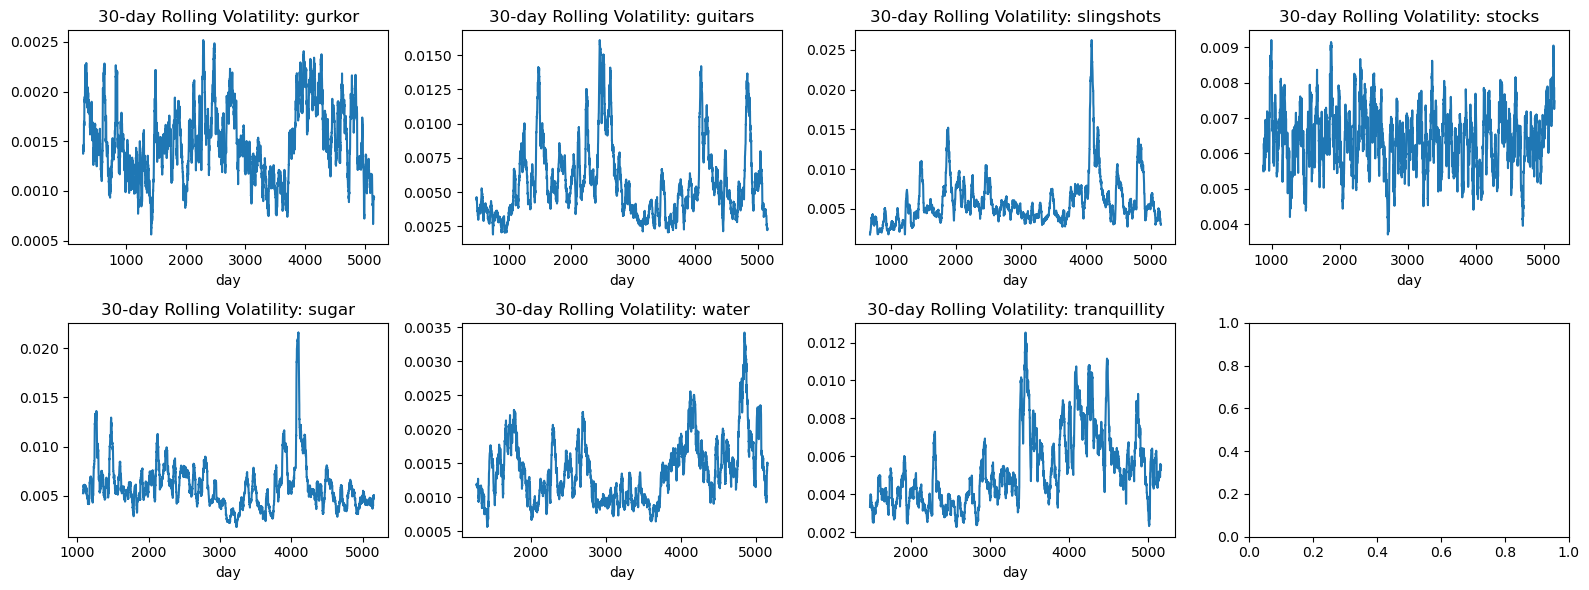

In [205]:
if "dis_summary_clean" not in globals() or "df" not in globals() or "target_cols" not in globals():
    raise RuntimeError("Run distribution and data loading cells first.")

ROLLING_DIR = Path("Rolling_Volatility")
Path.mkdir(CHART_DIR / ROLLING_DIR, exist_ok=True)

nrows = 2
ncols = len(target_cols)//2 +(len(target_cols)%2 !=0)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

axes = axes.flatten()
for i, col in enumerate(target_cols):
    name = col.split('_')[0]

    intervals = get_valid_segments_fixed(df_clean[col])
    st, ed = max(intervals, key=lambda x: df_clean[col].loc[x[0]:x[1]].shape[0])

    largest_segment = df_clean[col].loc[st:ed]
    largest_segment.rolling(30).std().plot(title=f"30-day Rolling Volatility: {name}", ax=axes[i])
fig.tight_layout()
plt.show()

While the QQ-plots establish the presence of leptokurtosis ("fat tails"), the Rolling Volatility visually identifies "when" the cluster occurs, the ACF/PACF analysis on the largest continuous segment adds another critical structures, helping quantify the decay rate of that turbulence. By estimating these on the largest continuous segment, we isolate the asset's "true" dependency structure from structural breaks, providing visual confirmation of stationarity and mean-reversion speed. This confirms whether the observed extremes are isolated shocks or part of a stationary, mean-reverting system with quantifiable persistence

**Dependency Identification:** The ACF captures the total memory (both direct and indirect) of past returns, while the PACF isolates the pure impact of specific lags. Together, they allow us to identify significant short-term dependencies and potential Autoregressive (AR) models, ensuring our inferences are free from the biases typically introduced by missing data blocks.
- 


**Linear vs. Non-linear Dynamics:** The log-returns reveal the degree of linear efficiency and potential short-term predictability in price movements. In contrast, the squared log-returns provide critical insights into the persistence of volatility clustering and risk memory.the squared returns quantify the persistence of volatility clustering and risk memory. 
- 

Note that significance is determined by the 95% confidence intervals; bars extending beyond this threshold indicate non-random temporal dependence. For the cleaned log-returns, we expect most lags to be statistically insignificant, confirming that the series approximates a white noise process with minimal residual memory beyond the first few lags.

Addtionally, we also apply both the Augmented Dickey–Fuller (ADF) and KPSS tests in a complementary manner to each segment independently. This dual-testing approach leverages their opposing null hypotheses to ensure robust stationarity across the entire timeline. From the result, consistency in achieving low ADF p-values ($p \lt 0.05$) and high KPSS p-values ($p>0.05$) across the primary segments confirms that the log-returns are strongly stationary and free from unit roots or deterministic trends.

Temporal analysis:


,adf_pvalue,adf_stationary,kpss_pvalue,kpss_stationary,segments,lb_pvalue,lb2_pvalue
gurkor_logreturn,"['1.53e-24', '1.78e-28']",True,"['0.1000', '0.1000']",True,"[(0, 197), (246, 5157)]",0.000006,0.000000
guitars_logreturn,"['0.00e+00', '2.99e-20']",True,"['0.1000', '0.1000']",True,"[(0, 391), (440, 5157)]",0.001695,0.000000
slingshots_logreturn,"['0.00e+00', '1.39e-22']",True,"['0.1000', '0.1000']",True,"[(0, 588), (637, 5157)]",0.000008,0.000000
stocks_logreturn,"['0.00e+00', '0.00e+00']",True,"['0.1000', '0.1000']",True,"[(0, 787), (836, 5157)]",0.261698,0.341822
sugar_logreturn,"['0.00e+00', '0.00e+00']",True,"['0.1000', '0.1000']",True,"[(0, 985), (1033, 5157)]",0.000134,0.000000
water_logreturn,"['0.00e+00', '0.00e+00']",True,"['0.1000', '0.1000']",True,"[(0, 1182), (1231, 5157)]",0.004685,0.000000
tranquillity_logreturn,"['1.45e-19', '0.00e+00']",True,"['0.0905', '0.1000']",True,"[(0, 1382), (1431, 5157)]",0.028569,0.000000


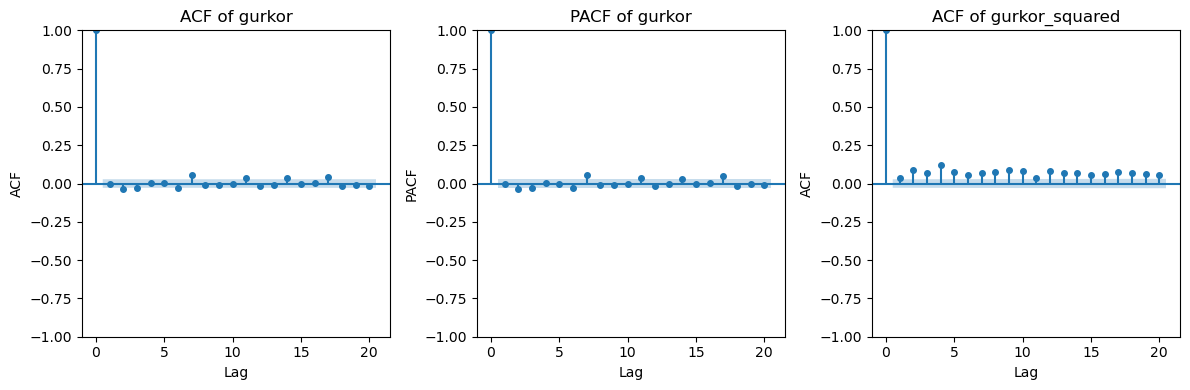

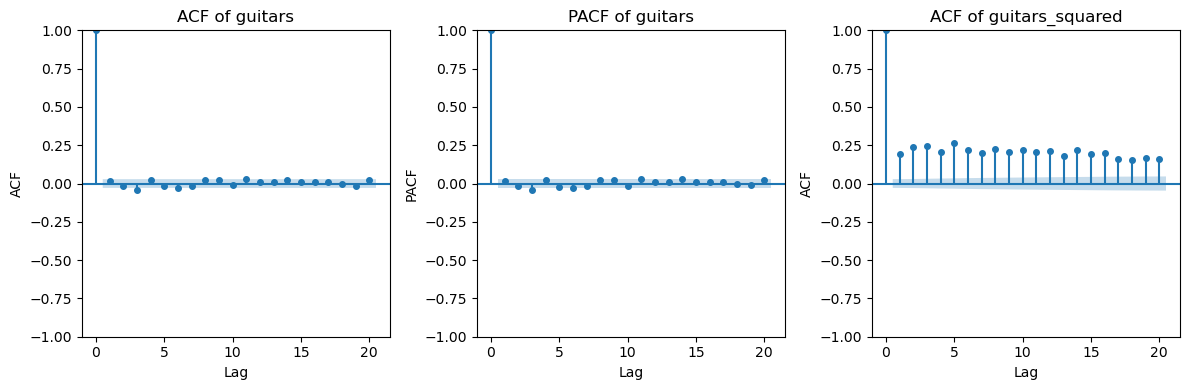

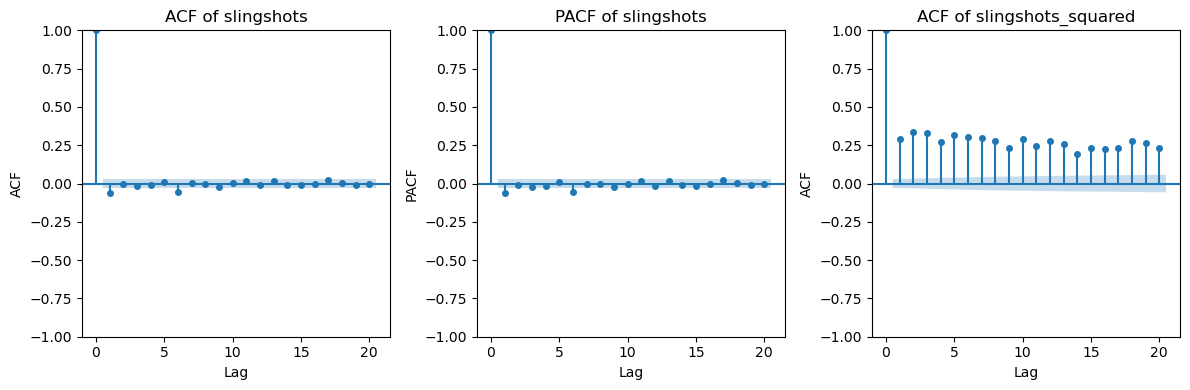

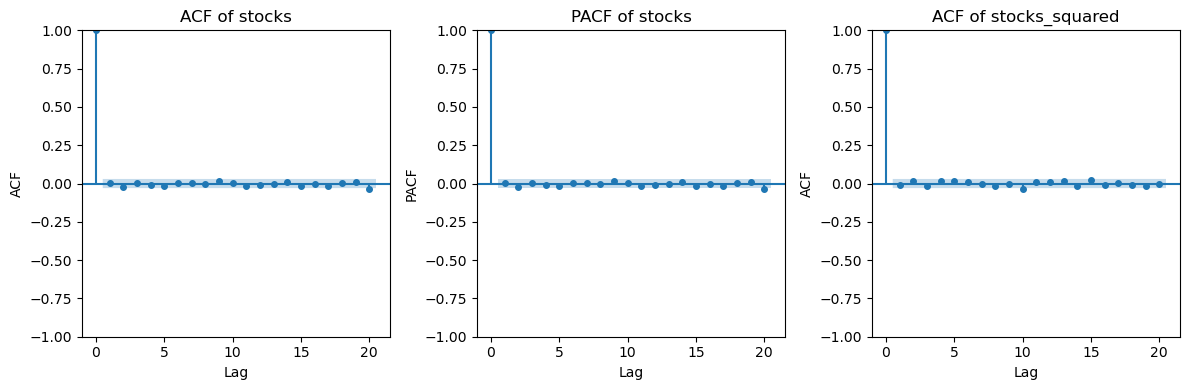

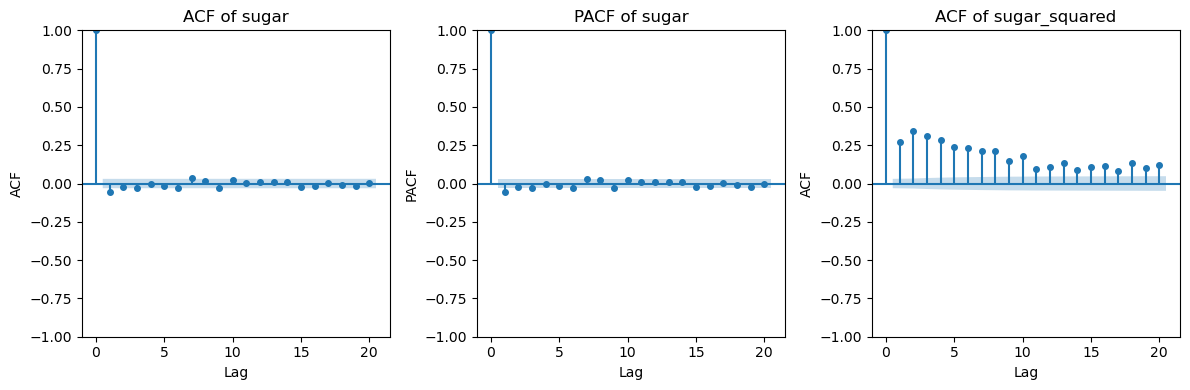

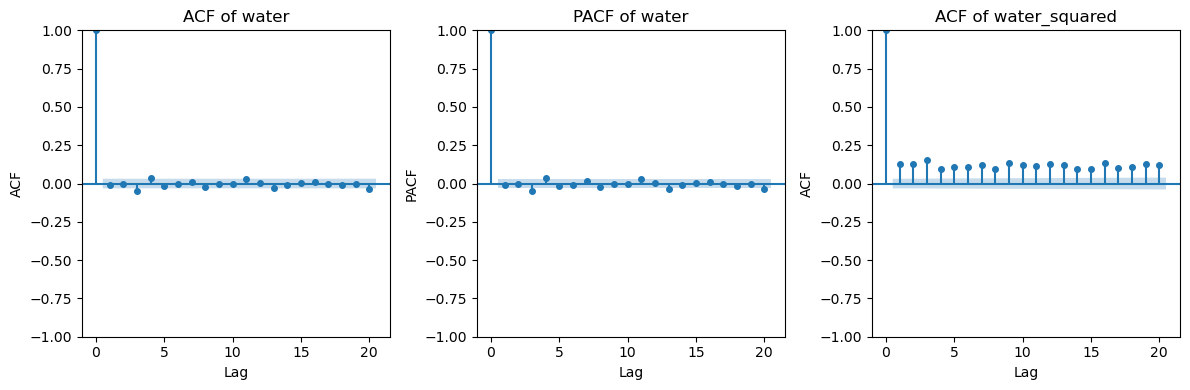

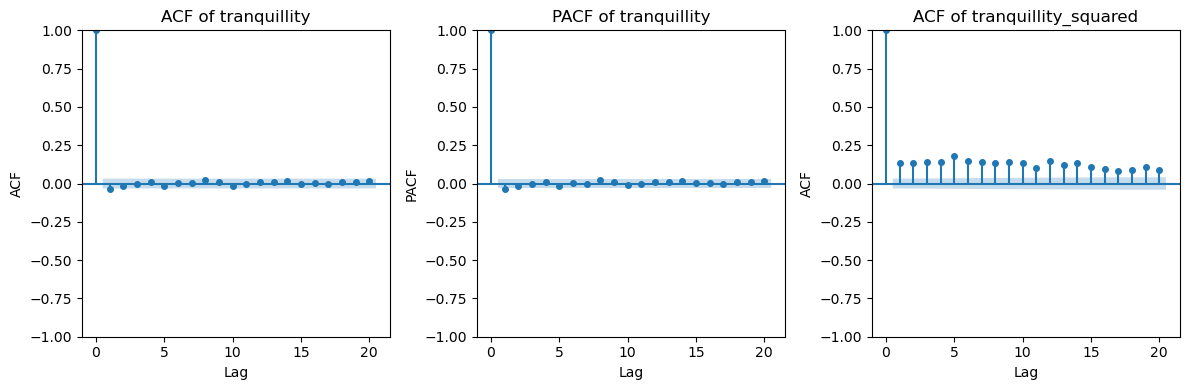

In [206]:
if "df_clean" not in globals():
    raise RuntimeError("Run the data loading cell first.")

temporal_summary = temporal_analysis(df_clean)
print("Temporal analysis:")
display(temporal_summary.style.format({
    "adf_pvalue": lambda x: [f"{i:.2e}" for i in x] if isinstance(x, list) else x,
    "kpss_pvalue": lambda x: [f"{i:.4f}" for i in x] if isinstance(x, list) else x
}))

,gurkor_logreturn,guitars_logreturn,slingshots_logreturn,stocks_logreturn,sugar_logreturn,water_logreturn,tranquillity_logreturn
gurkor_logreturn,1.000000,-0.237049,-0.208796,-0.047029,-0.069225,0.553591,-0.135113
guitars_logreturn,-0.237049,1.000000,0.506524,0.017684,0.171336,-0.218286,0.207746
slingshots_logreturn,-0.208796,0.506524,1.000000,0.010735,0.110866,-0.189008,0.180585
stocks_logreturn,-0.047029,0.017684,0.010735,1.000000,-0.003913,-0.037255,0.011252
sugar_logreturn,-0.069225,0.171336,0.110866,-0.003913,1.000000,-0.081996,0.106315
water_logreturn,0.553591,-0.218286,-0.189008,-0.037255,-0.081996,1.000000,-0.148766
tranquillity_logreturn,-0.135113,0.207746,0.180585,0.011252,0.106315,-0.148766,1.000000


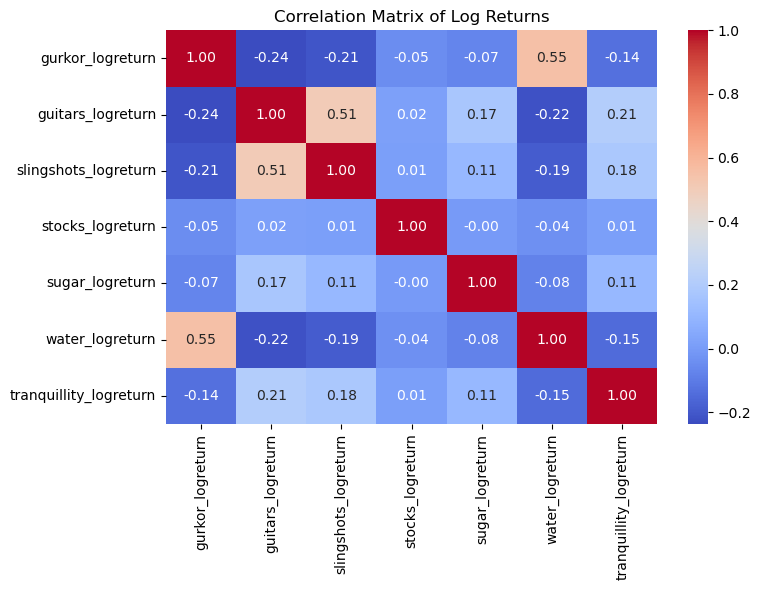

In [ ]:
if "df_clean" not in globals():
    raise RuntimeError("Run the data loading cell first.")

corr_matrix = correlation_analysis(df_clean.dropna(), min_periods=30)
display(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Log Returns")
plt.tight_layout()
# plt.savefig(CHART_DIR / "Correlation_Matrix.jpg", dpi=180)
plt.show()
# plt.close()

We then calculated the correlation matrix for the asset series to quantify their linear linkages.
- **Overall Portfolio Heterogeneity** <br>
The majority of asset pairs exhibit near-zero or weak correlations (mostly between -0.2 and 0.2), indicating a high degree of asset independence. This suggests the portfolio is well-diversified and the underlying "log returns" are driven by distinct fundamental factors.
- **Low Explanatory Power(R^2)** <br>
The highest positive correlations observed are guitars vs. slingshots (0.51) and gurkor vs. water (0.55) remain moderate. Even in these cases, the coefficient of determination (
) is only about 25%–30%, meaning over 70% of each asset's volatility is independent of its pair.
- **Near-Zero Correlated "Anchors"** <br>
"Stocks_logreturn" stands out as a "neutral anchor," showing virtually zero correlation with any other asset in the list. This lack of linear relationship makes it a powerful component for reducing overall portfolio variance.
- **Potential Hedging Opportunities** <br>
Several pairs show negative correlations, such as gurkor vs. guitars (-0.24) and gurkor vs. slingshots (-0.21). These inverse relationships are ideal for risk mitigation, as losses in one asset may be partially offset by gains in the other during specific market conditions.

We further analyze the two most relevant pairs **guitars vs. slingshots (0.51)** and **gurkor vs. water (0.55)** by rolling and partial correlations to distinguish between "static noise" and "dynamic signals".

In [109]:
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def rolling_correlation_analysis(df: pd.DataFrame, col1: str, col2: str, window_size=200, min_periods=100) -> pd.Series:
    c = df[col1].corr(df[col2], min_periods=min_periods)
    rolling_c = df[col1].rolling(window=window_size, min_periods=min_periods).corr(df[col2])
    plt.figure(figsize=(12, 4))
    rolling_c.plot(color='royalblue', label=f'Rolling Corr')
    plt.axhline(c, color='red', linestyle='--', alpha=0.6, label='Correlation')
    plt.title(f"Rolling Correlation between {col1} and {col2}")
    plt.xlabel("Day")
    plt.ylabel("Correlation")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
def partial_correlation_analysis(df: pd.DataFrame, col1: str, col2: str, window_size=200, min_periods=100) -> pd.Series:
    # market_factor = df.mean(axis=1) # use the average of all columns as a proxy for the market factor
    # Sign Cancellation: a simple mean over those inversely correlated assets will flatten the variance, failing to capture the true underlying market stress.
    
    # PCA is sensitive to missing values, so we take a subset of the data that has no missing values for PCA
    df_perfect = df.iloc[1500:5000] 
    # we ensure that the same correlation pattern can be derived from the perfect data to make sure the PCA is working correctly
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df_perfect)    
    pca = PCA(n_components=1)
    pca.fit(scaled_data)
    weights = pca.components_[0] # (n_features,)

    df_scaled = (df - scaler.mean_) / scaler.scale_
    market_factor = (df_scaled * weights).sum(axis=1)

    '''   
    for col in [col1, col2]:
        if df[col].isna().any():
            print(f"Warning: {col} contains NaN values. Filling with forward/backward fill for PCA and regression.")
            temp_df = df[col1].fillna(method='ffill').fillna(method='bfill')
            scaler = StandardScaler()

    scaled_data = scaler.fit_transform(temp_df)

    # Use PCA to extract the first principal component as the market factor
    pca = PCA(n_components=1)
    market_factor = pca.fit_transform(df.dropna().values).flatten()  
    '''
    
    def get_residual(target, market):
        valid_mask = target.notna() & market.notna()
        model = LinearRegression().fit(market[valid_mask].values.reshape(-1, 1), target[valid_mask])
        res = target.copy()
        res[valid_mask] = target[valid_mask] - model.predict(market[valid_mask].values.reshape(-1, 1))
        return res

    # get residuals for both columns after regressing out the market factor
    res_a = get_residual(df_scaled[col1], market_factor)
    res_b = get_residual(df_scaled[col2], market_factor)

    # calculate rolling correlation of the residuals to get the partial correlation
    partial_corr = res_a.corr(res_b)
    print(f"Original correlation between {col1} and {col2}: {df_scaled[col1].corr(df_scaled[col2]):.3f}")
    print(f"Partial correlation(after removing the market factor): {partial_corr:.3f}")

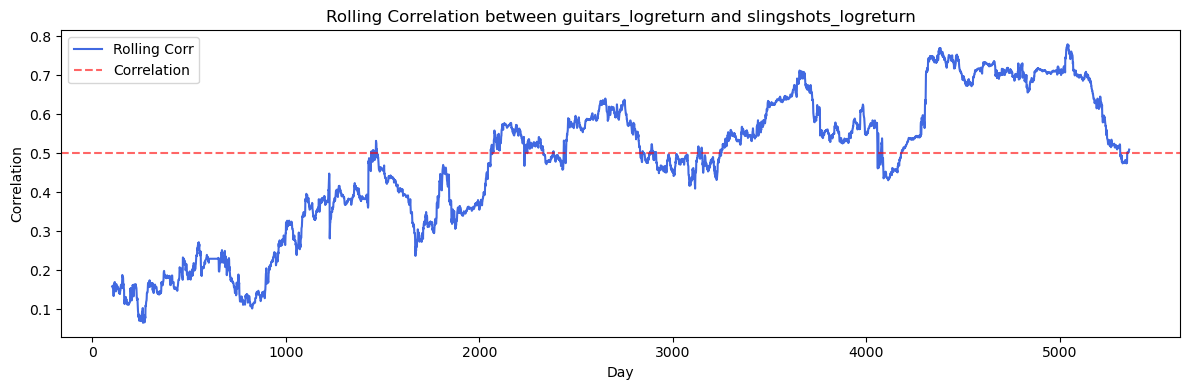

Original correlation between guitars_logreturn and slingshots_logreturn: 0.501
Partial correlation(after removing the market factor): 0.106


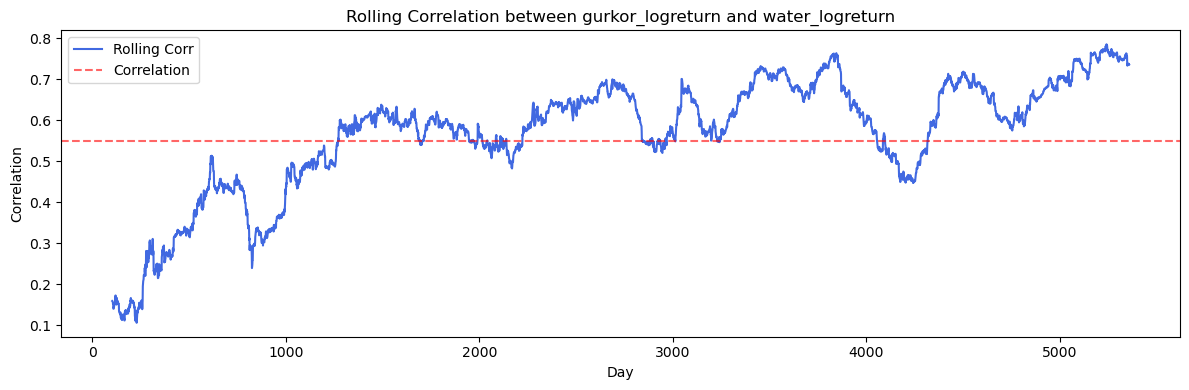

Original correlation between gurkor_logreturn and water_logreturn: 0.550
Partial correlation(after removing the market factor): 0.156


In [185]:
Pairs = [("guitars", "slingshots"), ("gurkor", "water")]
for i in Pairs:
    x, y = i
    rolling_correlation_analysis(df_clean, x+"_logreturn", y+"_logreturn", window_size=200, min_periods=100)
    partial_correlation_analysis(df_clean, x+"_logreturn", y+"_logreturn", window_size=200, min_periods=100)
